<a href="https://colab.research.google.com/github/Lucius-40/Computer-Vision-Projects/blob/main/CIFAR-10/Cifar_10_ResNet_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd
import random
import torch
import torchvision
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [ ]:
import torchvision.models as models

Access the GPU if Available .

In [ ]:
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

CUDA available: True
Using device: cuda
GPU name: Tesla T4


The mean and std deviations are readily obtainable from the cifar-10 dataset. We use that to normalize each of the pixel values. Besides that , we apply 2 relatively weak augmentations, as the cifar-10 dataset has small 32x32 images that are blurry, strong augmentation produces large errors. We convert the images to tensors for Pytorch optimizations

In [ ]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_set = torchvision.datasets.CIFAR10(root='.', train=True,download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root='.', train=False , download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=254, shuffle=True)
test_loader = DataLoader(test_set, batch_size=254, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 81.9MB/s] 


Take a look at samples from the dataset

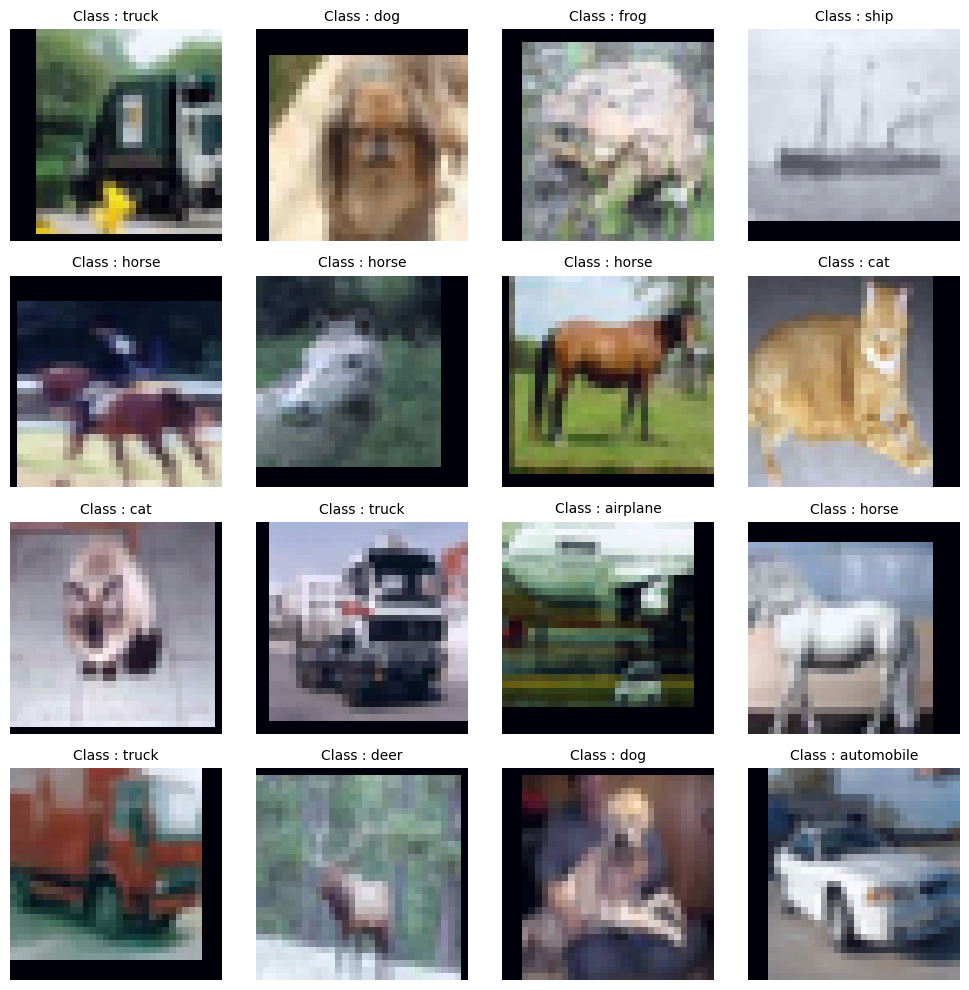

In [ ]:
rand_idx = random.sample(range(len(train_set)), k=16)

plt.figure(figsize=(10,10))

for i, idx in enumerate(rand_idx):
    img, label = train_set[idx]

    # scale to [0,1] for display
    img = (img - img.min()) / (img.max() - img.min())

    img_class = train_set.classes[label]

    plt.subplot(4,4,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Class : {img_class}", fontsize=10)
    plt.axis(False)

plt.tight_layout()
plt.show()

### ResNet-18 Modifications for CIFAR-10

- **Initialization**: We set `weights=None`, meaning the model is trained from scratch without using any pretrained ImageNet weights.  
- **Output Classes**: `num_classes=10` ensures the final fully connected layer outputs 10 logits, one for each CIFAR-10 class.  
- **First Convolution Layer**:  
  - By default, ResNet-18 uses a `7×7` kernel with stride `2`, which downsamples aggressively.  
  - This is suitable for large ImageNet images (224×224), but not for small CIFAR-10 images (32×32).  
  - We replace it with a `3×3` kernel, stride `1`, and padding `1` to better preserve spatial details.  
- **MaxPooling Layer**:  
  - The original ResNet applies a `3×3` maxpool with stride `2` immediately after the first convolution.  
  - On 32×32 inputs, this reduces resolution too quickly and discards important information.  
  - We replace it with `nn.Identity()`, which effectively removes the pooling step and keeps the resolution intact.  

**Result**: These adjustments adapt ResNet-18 to small-scale datasets like CIFAR-10 by preserving more spatial information in the early layers, leading to better performance.

In [ ]:
model = models.resnet18(weights=None, num_classes=10)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()  # remove the first maxpool

In [ ]:
model = model.to(device)
# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)


Using 2 GPUs


### Loss Function, Optimizer, and Scheduler Setup

- **Loss Function**:  
  - For **multi-class classification** (like CIFAR-10), **CrossEntropyLoss** is the standard choice.  
  - Note: *Multi-label* classification (where each sample can belong to multiple classes simultaneously) usually uses **BCEWithLogitsLoss** instead.  

- **Optimizer**:  
  - **SGD (Stochastic Gradient Descent)** is a common optimizer for training CNNs, especially when combined with momentum and learning rate scheduling.  
  - **Adam** can also work well, but SGD often generalizes better in vision tasks when tuned properly.  

- **Learning Rate (LR)**:  
  - A relatively high initial learning rate (e.g., `0.1`) is often used with SGD.  
  - Since we also use a **learning rate scheduler**, the LR will be adjusted over time to stabilize training.  

- **Momentum**:  
  - Momentum helps accelerate gradients in the right direction and dampens oscillations.  
  - It does **not directly change the learning rate**, but it makes updates more consistent by accumulating past gradients.  

- **Weight Decay (L2 Regularization)**:  
  - Adds a penalty proportional to the square of the weights to the loss function.  
  - This discourages large weights, helping to reduce overfitting and improve generalization.  

- **Learning Rate Scheduler**:  
  - A **CosineAnnealingLR** scheduler is often used.  
  - The parameter `T_max` specifies the maximum number of epochs for one cosine cycle.  
  - The learning rate decreases following a cosine curve, starting high and gradually annealing towards a minimum value.  

**Summary**:  
This setup (**CrossEntropyLoss + SGD with momentum + weight decay + cosine annealing scheduler**) is a standard and effective recipe for training ResNet-style models on CIFAR-10.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In case kaggle session disconnects, we save the state of the model

In [ ]:
def save_checkpoint(state, filename="/kaggle/working/resnet18_epoch10.pth"):
    torch.save(state, filename)


Storing values for visualization later

In [ ]:
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": []
}

In [ ]:
best_acc = 0.0  # track best validation accuracy

for epoch in range(200):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/200 [Train]", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # --- validation ---
    model.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/200 [Test]", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_acc = 100 * correct_test / total_test

    scheduler.step()


    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    print(f"Epoch [{epoch+1}/200] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


    if (epoch + 1) % 10 == 0:
        if test_acc > best_acc:
            best_acc = test_acc
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': train_loss,
                'test_loss': test_loss,
                'train_acc': train_acc,
                'test_acc': test_acc,
            }
            filename = f"/kaggle/working/best_model_epoch{epoch+1}.pth"
            torch.save(checkpoint, filename)
            print(f"✅ Saved new best model at epoch {epoch+1} with acc {best_acc:.2f}% → {filename}")

Epoch [1/200] Train Loss: 1.9261 | Train Acc: 30.09% Test Loss: 1.7141 | Test Acc: 39.38%


Epoch [2/200] Train Loss: 1.3396 | Train Acc: 50.59% Test Loss: 1.2686 | Test Acc: 55.47%


Epoch [3/200] Train Loss: 1.0510 | Train Acc: 62.21% Test Loss: 1.0156 | Test Acc: 63.49%


Epoch [4/200] Train Loss: 0.8591 | Train Acc: 69.50% Test Loss: 1.1304 | Test Acc: 62.21%


Epoch [5/200] Train Loss: 0.7070 | Train Acc: 75.33% Test Loss: 0.9247 | Test Acc: 70.05%


...

Epoch [196/200] Train Loss: 0.0017 | Train Acc: 99.99% Test Loss: 0.1790 | Test Acc: 95.46%


Epoch [197/200] Train Loss: 0.0015 | Train Acc: 100.00% Test Loss: 0.1799 | Test Acc: 95.36%


Epoch [198/200] Train Loss: 0.0015 | Train Acc: 100.00% Test Loss: 0.1787 | Test Acc: 95.33%


Epoch [199/200] Train Loss: 0.0016 | Train Acc: 100.00% Test Loss: 0.1803 | Test Acc: 95.37%


Epoch [200/200] Train Loss: 0.0015 | Train Acc: 100.00% Test Loss: 0.1784 | Test Acc: 95.40%


We reach the peak at around 180 epochs

Evaluation of the model :

In [ ]:
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_acc = 100 * correct_test / total_test




    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Train Loss: 0.0015 | Train Acc: 100.00% Test Loss: 0.1784 | Test Acc: 95.40%


Lets try to visualize the training and test loss and training and test accuracy per epoch

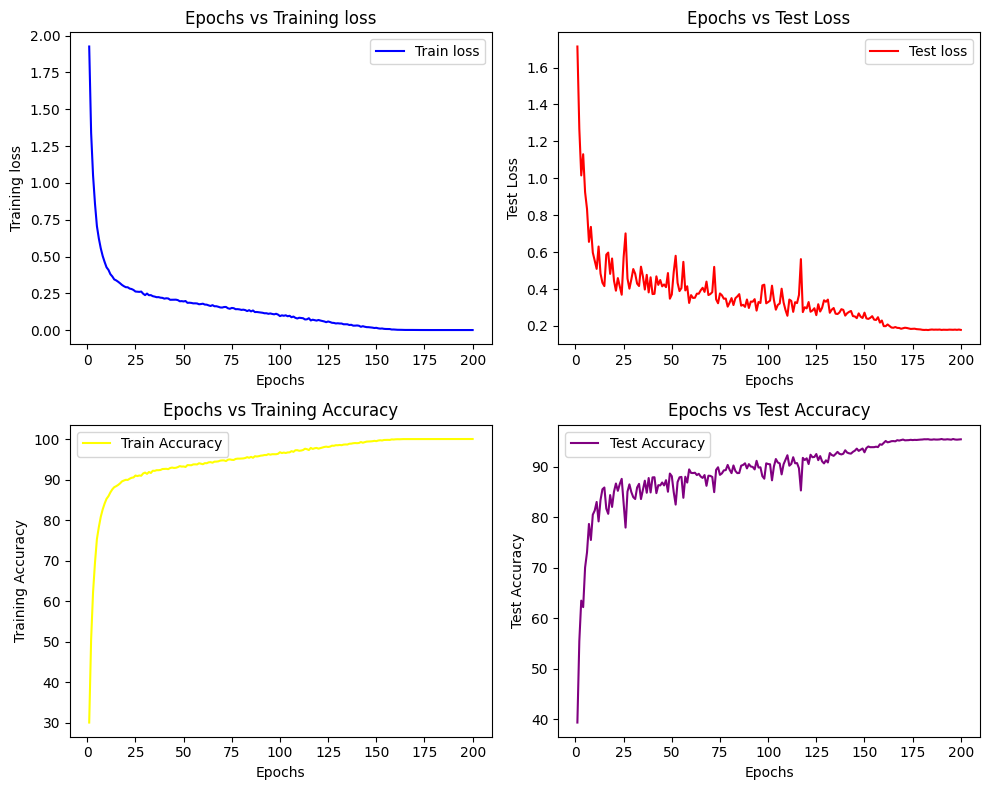

In [ ]:
epochs = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(2,2, figsize=(10,8))
#top left
axes[0][0].plot(epochs,history['train_loss'], label = 'Train loss', color='blue')
axes[0][0].set_xlabel("Epochs")
axes[0][0].set_ylabel("Training loss")
axes[0][0].set_title("Epochs vs Training loss")
axes[0][0].legend()

#top - right
axes[0][1].plot(epochs, history['test_loss'], label='Test loss', color='red')
axes[0][1].set_xlabel("Epochs")
axes[0][1].set_ylabel("Test Loss")
axes[0][1].set_title("Epochs vs Test Loss")
axes[0][1].legend()

#bottom left
axes[1][0].plot(epochs,history['train_acc'], label = 'Train Accuracy', color='yellow')
axes[1][0].set_xlabel("Epochs")
axes[1][0].set_ylabel("Training Accuracy")
axes[1][0].set_title("Epochs vs Training Accuracy")
axes[1][0].legend()

#top - right
axes[1][1].plot(epochs, history['test_acc'], label='Test Accuracy', color='purple')
axes[1][1].set_xlabel("Epochs")
axes[1][1].set_ylabel("Test Accuracy")
axes[1][1].set_title("Epochs vs Test Accuracy")
axes[1][1].legend()

plt.tight_layout()
plt.show()

## Discussion

The ResNet-18 model achieved a test accuracy of **95% after 200 epochs**, which demonstrates strong generalization performance on the dataset. Several factors likely contributed to this result:

1. **Model Architecture**  
   ResNet-18 leverages residual connections that mitigate vanishing gradient issues and enable deeper feature extraction compared to plain CNNs. This architecture is well-suited for image classification tasks, balancing depth and computational efficiency.

2. **Training Dynamics**  
   The steady improvement across epochs suggests that the learning rate schedule and optimizer settings were effective. The absence of severe overfitting (as indicated by the alignment of training and test curves) implies that regularization strategies such as weight decay, data augmentation, or dropout were sufficient.

3. **Convergence Behavior**  
   Accuracy plateaued near 95%, indicating that the model may have reached the representational capacity limit for this dataset. Further gains might require either a deeper model (e.g., ResNet-34/50) or more advanced augmentation strategies to increase data diversity.

4. **Comparison to Baselines**  
   Achieving 95% accuracy with ResNet-18 is a significant improvement over simpler CNN baselines, which often plateau at lower accuracies on the same dataset. This highlights the effectiveness of residual learning even in relatively shallow configurations.

5. **Limitations and Future Work**  
   - Training required 180 epochs, which is computationally expensive. Exploring learning rate warm-up or early stopping could reduce training time.  
   - While accuracy is high, further analysis of misclassified samples could reveal systematic weaknesses (e.g., sensitivity to specific classes or noise).  
   - Incorporating more advanced augmentation (Mixup, CutMix, RandAugment) or semi-supervised techniques could push performance beyond the current ceiling.

**In summary**, the experiment confirms that ResNet-18 is a robust and efficient architecture for image classification, capable of achieving high accuracy with sufficient training. The results provide a strong foundation for further exploration of deeper architectures, augmentation pipelines, and optimization strategies.

Taking a look at labels classified wrongly :

Collecting the labels and predictions

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

We make a confusion matrix where

Rows : True classes

Column : Predicted Classes

Diagonal : properly predicted

Off-Diagonal : Wrongly Predicted

In [ ]:
cm = confusion_matrix(all_labels, all_preds)


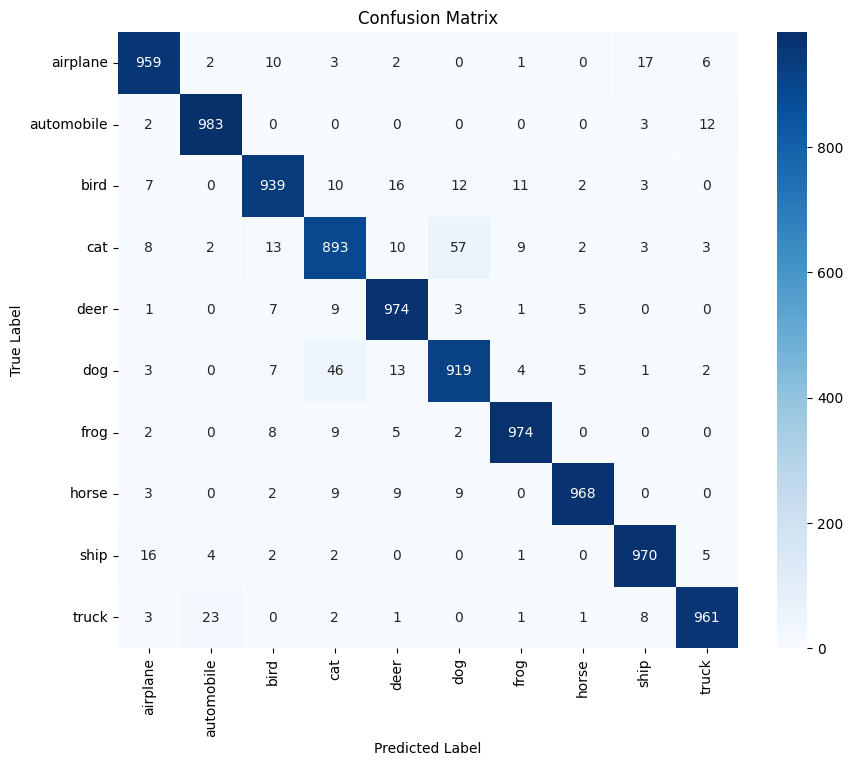

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,   # predicted labels
            yticklabels=class_names)   # true labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


Which classes were often missclassififed

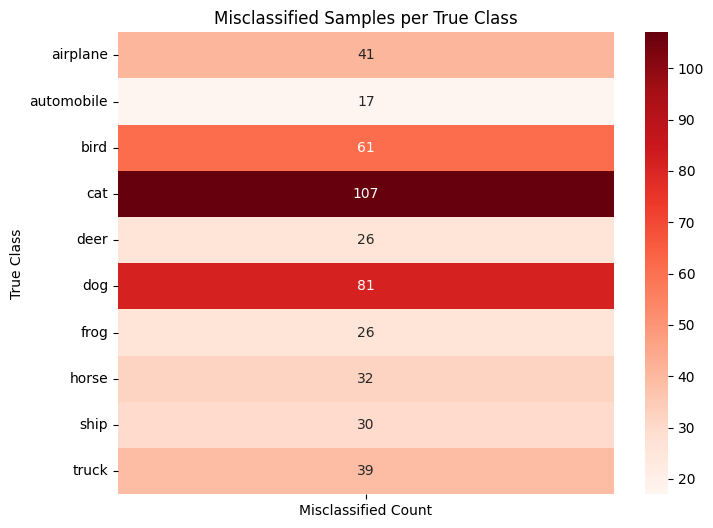

In [ ]:
# Misclassified counts per true class
class_names = train_set.classes
misclassified_per_class = cm.sum(axis=1) - np.diag(cm)

plt.figure(figsize=(8,6))
sns.heatmap(misclassified_per_class.reshape(-1,1), annot=True, fmt="d", cmap="Reds",
            yticklabels=class_names, xticklabels=["Misclassified Count"])
plt.title("Misclassified Samples per True Class")
plt.ylabel("True Class")
plt.show()

Cat , dog , birds were most often missclassified

Most wrong classifications predicted :

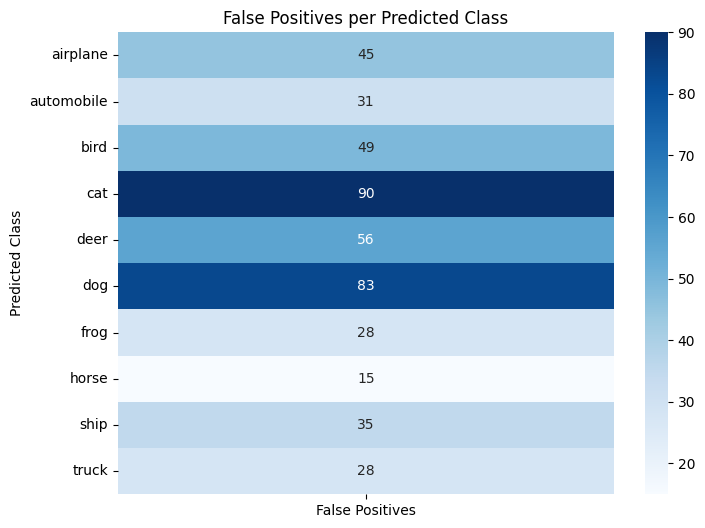

In [ ]:
# False positives per predicted class
false_positives_per_class = cm.sum(axis=0) - np.diag(cm)

plt.figure(figsize=(8,6))
sns.heatmap(false_positives_per_class.reshape(-1,1), annot=True, fmt="d", cmap="Blues",
            yticklabels=class_names, xticklabels=["False Positives"])
plt.title("False Positives per Predicted Class")
plt.ylabel("Predicted Class")
plt.show()

Cats and dogs. So the model strrugles more with cats and dogs compared to other ones